In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
# Loading datasets
trader_data = pd.read_csv('/content/Historical Data.csv')
sentiment_data = pd.read_csv('/content/Fear Greed Index.csv')




In [ ]:
print(f"Trader Data Shape: {trader_data.shape}")
print(f"Sentiment Data Shape: {sentiment_data.shape}")

Trader Data Shape: (211224, 16)
Sentiment Data Shape: (2644, 4)


In [ ]:
# Check for missing values and data types
print(trader_data.info())
print(sentiment_data.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [ ]:
# Examine trader data structure
print("=== TRADER DATA OVERVIEW ===")
print("Columns:", trader_data.columns.tolist())
print("\nFirst 5 rows:")
print(trader_data.head())
print("\nData types:")
print(trader_data.dtypes)
print("\nBasic statistics:")
print(trader_data.describe())


=== TRADER DATA OVERVIEW ===
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

First 5 rows:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Bu

In [ ]:
# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

In [ ]:
# Examine sentiment data structure
print("=== SENTIMENT DATA OVERVIEW ===")
print("Columns:", sentiment_data.columns.tolist())
print("\nFirst 5 rows:")
print(sentiment_data.head())
print("\nData types:")
print(sentiment_data.dtypes)
print("\nUnique classifications:")
if 'classification' in sentiment_data.columns:
    print(sentiment_data['classification'].value_counts())

# Check for missing values
print("=== DATA QUALITY CHECK ===")
print("\n--- Trader Data Missing Values ---")
print(trader_data.isnull().sum())
print("\n--- Sentiment Data Missing Values ---")
print(sentiment_data.isnull().sum())

# Check date columns and formats
print("\n--- Date Column Analysis ---")
date_cols = [col for col in trader_data.columns if 'date' in col.lower() or 'time' in col.lower()]
print("Potential date columns in trader data:", date_cols)

date_cols_sentiment = [col for col in sentiment_data.columns if 'date' in col.lower() or 'time' in col.lower()]
print("Potential date columns in sentiment data:", date_cols_sentiment)

# Converting date columns to datetime format


# For trader data - common column names are 'time', 'timestamp', 'date'
trader_data['date'] = pd.to_datetime(trader_data['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
trader_data['date_only'] = trader_data['date'].dt.date

# For sentiment data - adjust column name as needed
sentiment_data['date_converted'] = pd.to_datetime(sentiment_data['date'], errors='coerce')
sentiment_data['date_only'] = sentiment_data['date_converted'].dt.date

print("✅ Date columns standardized")
print(f"Trader data date range: {trader_data['date'].min()} to {trader_data['date'].max()}")
print(f"Sentiment data date range: {sentiment_data['date_converted'].min()} to {sentiment_data['date_converted'].max()}")

=== SENTIMENT DATA OVERVIEW ===
Columns: ['timestamp', 'value', 'classification', 'date']

First 5 rows:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Data types:
timestamp          int64
value              int64
classification    object
date              object
dtype: object

Unique classifications:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64
=== DATA QUALITY CHECK ===

--- Trader Data Missing Values ---
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Orde

In [ ]:
# Merging datasets on date
merged_data = trader_data.merge(
    sentiment_data[['date_only', 'classification']],
    on='date_only',
    how='left'
)

print(f"Merged dataset shape: {merged_data.shape}")
print(f"Rows with sentiment data: {merged_data['classification'].notna().sum()}")
print("\nSentiment distribution:")
print(merged_data['classification'].value_counts())

Merged dataset shape: (211224, 19)
Rows with sentiment data: 211218

Sentiment distribution:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [ ]:
# Calculating key trading metrics

# Profitability metrics
merged_data['is_profitable'] = merged_data['Closed PnL'] > 0
merged_data['profit_ratio'] = merged_data['Closed PnL'] / merged_data['Size USD']  # Risk-adjusted return

# Volume and activity metrics
daily_summary = merged_data.groupby(['date_only', 'classification']).agg({
    'Size USD': ['sum', 'count'],
    'Closed PnL': ['sum', 'mean'],
    'is_profitable': 'mean'
}).round(4)

daily_summary.columns = ['total_volume_usd', 'trade_count', 'total_pnl', 'avg_pnl', 'win_rate']
daily_summary = daily_summary.reset_index()

print("✅ Key metrics calculated")
print("Daily summary sample:")
print(daily_summary.head())

✅ Key metrics calculated
Daily summary sample:
    date_only classification  total_volume_usd  trade_count  total_pnl  \
0  2023-05-01          Greed            477.00            3     0.0000   
1  2023-12-05  Extreme Greed          50005.83            9     0.0000   
2  2023-12-14          Greed         113203.35           11  -205.4347   
3  2023-12-15          Greed          10609.95            2   -24.6320   
4  2023-12-16          Greed          15348.77            3     0.0000   

   avg_pnl  win_rate  
0   0.0000    0.0000  
1   0.0000    0.0000  
2 -18.6759    0.3636  
3 -12.3160    0.0000  
4   0.0000    0.0000  


In [ ]:
# Validating the data quality
print("=== DATA VALIDATION ===")
print(f"Total days with data: {len(daily_summary)}")
print(f"Sentiment distribution:")
print(daily_summary['classification'].value_counts())

print(f"\nPnL Analysis:")
print(f"Days with zero PnL: {(daily_summary['total_pnl'] == 0).sum()}")
print(f"Days with positive PnL: {(daily_summary['total_pnl'] > 0).sum()}")
print(f"Days with negative PnL: {(daily_summary['total_pnl'] < 0).sum()}")

print(f"\nVolume ranges:")
print(f"Min volume: ${daily_summary['total_volume_usd'].min():.2f}")
print(f"Max volume: ${daily_summary['total_volume_usd'].max():.2f}")
print(f"Average volume: ${daily_summary['total_volume_usd'].mean():.2f}")


=== DATA VALIDATION ===
Total days with data: 479
Sentiment distribution:
classification
Greed            193
Extreme Greed    114
Fear              91
Neutral           67
Extreme Fear      14
Name: count, dtype: int64

PnL Analysis:
Days with zero PnL: 60
Days with positive PnL: 361
Days with negative PnL: 58

Volume ranges:
Min volume: $0.11
Max volume: $55914617.49
Average volume: $2486636.27


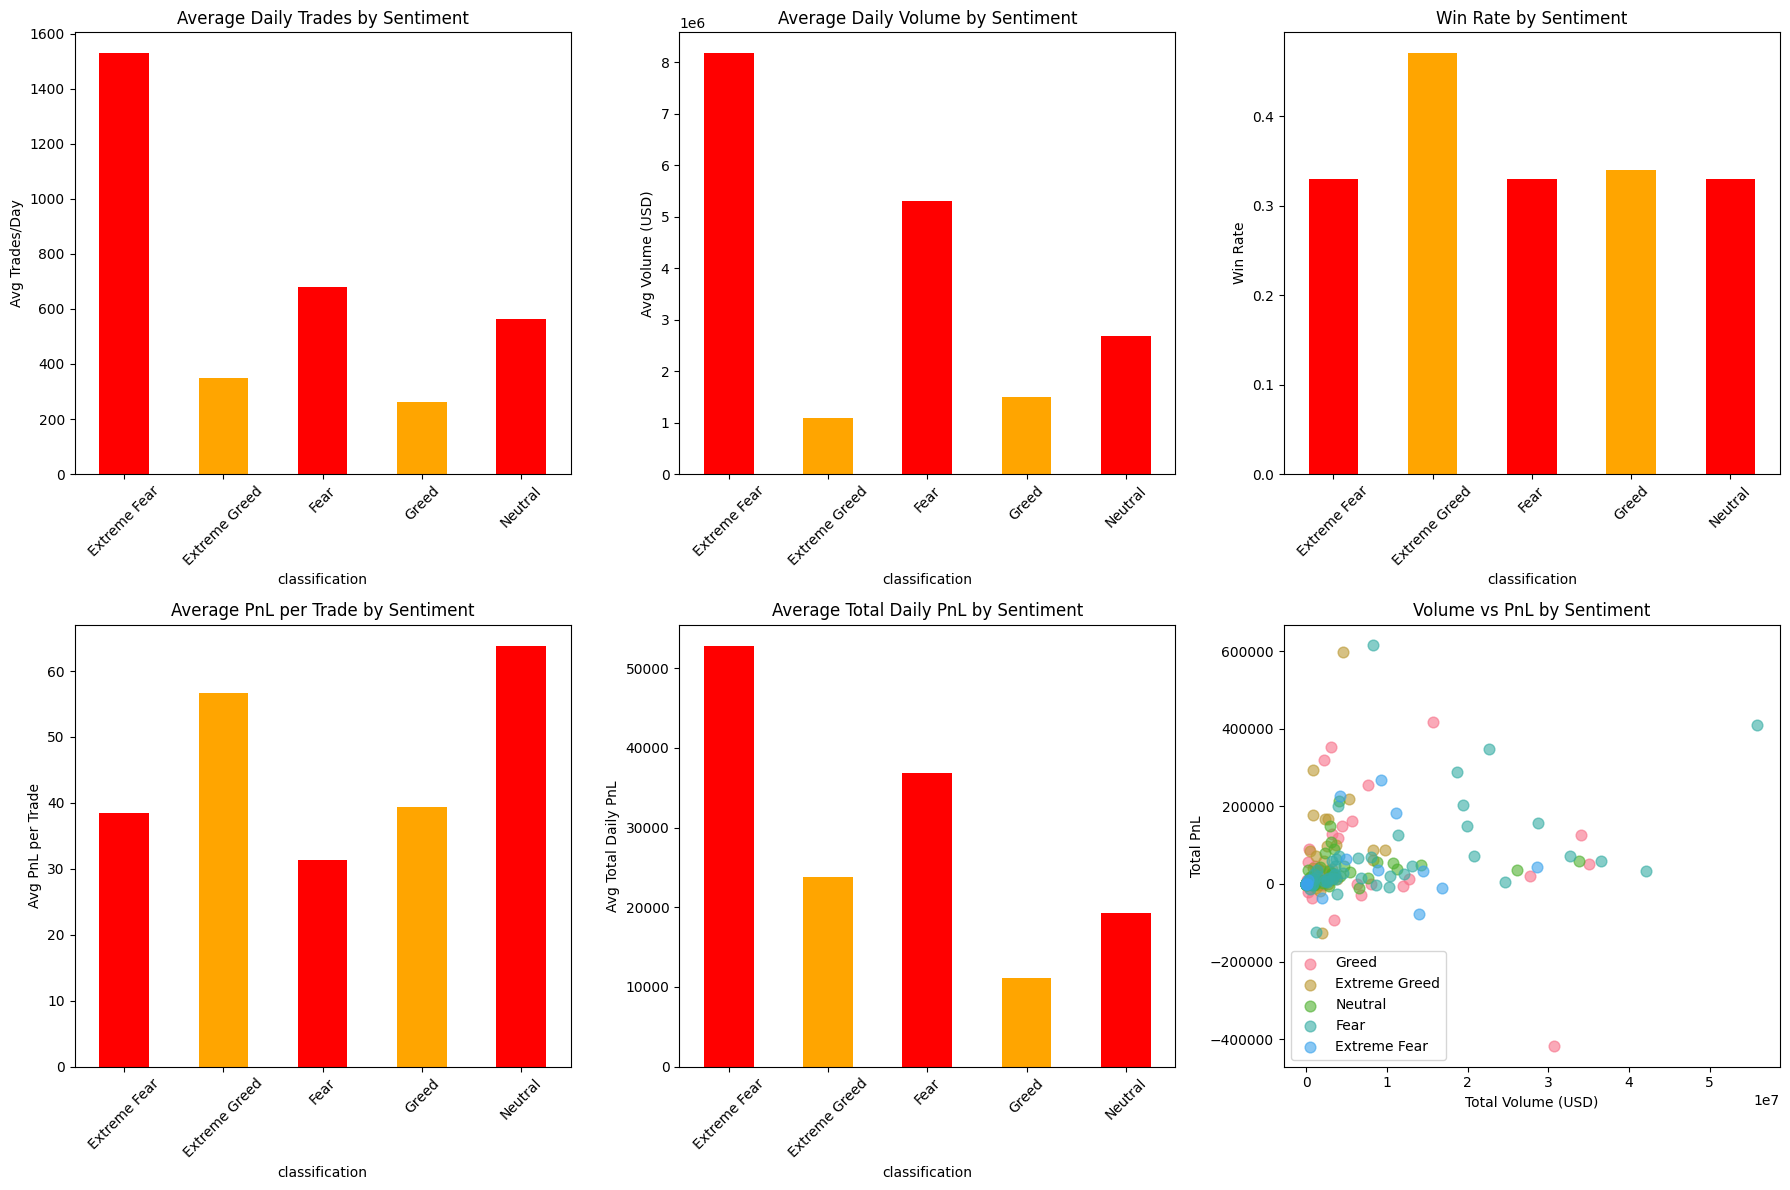

📊 Comprehensive analysis completed!

=== KEY FINDINGS ===
                trade_count  total_volume_usd  win_rate  avg_pnl  total_pnl
classification                                                             
Extreme Fear        1528.57        8177447.25      0.33    38.43   52793.59
Extreme Greed        350.81        1091799.69      0.47    56.74   23817.29
Fear                 679.53        5311261.43      0.33    31.28   36891.82
Greed                260.64        1495246.09      0.34    39.41   11140.57
Neutral              562.48        2690180.05      0.33    63.82   19297.32


In [ ]:
# Creating comprehensive visualization of trading patterns by sentiment
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Trade count by sentiment
sentiment_metrics = daily_summary.groupby('classification').agg({
    'trade_count': 'mean',
    'total_volume_usd': 'mean',
    'win_rate': 'mean',
    'avg_pnl': 'mean',
    'total_pnl': 'mean'
}).round(2)

sentiment_metrics['trade_count'].plot(kind='bar', ax=axes[0,0], color=['red', 'orange'])
axes[0,0].set_title('Average Daily Trades by Sentiment')
axes[0,0].set_ylabel('Avg Trades/Day')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Volume by sentiment
sentiment_metrics['total_volume_usd'].plot(kind='bar', ax=axes[0,1], color=['red', 'orange'])
axes[0,1].set_title('Average Daily Volume by Sentiment')
axes[0,1].set_ylabel('Avg Volume (USD)')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Win rate by sentiment
sentiment_metrics['win_rate'].plot(kind='bar', ax=axes[0,2], color=['red', 'orange'])
axes[0,2].set_title('Win Rate by Sentiment')
axes[0,2].set_ylabel('Win Rate')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. Average PnL by sentiment
sentiment_metrics['avg_pnl'].plot(kind='bar', ax=axes[1,0], color=['red', 'orange'])
axes[1,0].set_title('Average PnL per Trade by Sentiment')
axes[1,0].set_ylabel('Avg PnL per Trade')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Total daily PnL by sentiment
sentiment_metrics['total_pnl'].plot(kind='bar', ax=axes[1,1], color=['red', 'orange'])
axes[1,1].set_title('Average Total Daily PnL by Sentiment')
axes[1,1].set_ylabel('Avg Total Daily PnL')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Volume vs PnL scatter
for sentiment in daily_summary['classification'].unique():
    data = daily_summary[daily_summary['classification'] == sentiment]
    axes[1,2].scatter(data['total_volume_usd'], data['total_pnl'],
                     label=sentiment, alpha=0.6, s=60)
axes[1,2].set_title('Volume vs PnL by Sentiment')
axes[1,2].set_xlabel('Total Volume (USD)')
axes[1,2].set_ylabel('Total PnL')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('comprehensive_sentiment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("📊 Comprehensive analysis completed!")
print("\n=== KEY FINDINGS ===")
print(sentiment_metrics)


In [ ]:
# Save the processed data and key insights for your report
print("=== SAVING RESULTS ===")

# Save the daily summary data
daily_summary.to_csv('daily_trading_sentiment_analysis.csv', index=False)
print("✅ Daily summary saved to CSV")

# Save key insights for your report
sentiment_insights = daily_summary.groupby('classification').agg({
    'trade_count': ['mean', 'std'],
    'total_volume_usd': ['mean', 'std'],
    'win_rate': ['mean', 'std'],
    'avg_pnl': ['mean', 'std'],
    'total_pnl': ['mean', 'std']
}).round(4)

sentiment_insights.to_csv('sentiment_insights_summary.csv')
print("✅ Key insights saved for report")

# Display final summary for your report writing
print("\n=== KEY INSIGHTS FOR YOUR REPORT ===")
print("1. TRADING ACTIVITY:")
for sentiment in daily_summary['classification'].unique():
    data = daily_summary[daily_summary['classification'] == sentiment]
    print(f"   {sentiment}: Avg {data['trade_count'].mean():.1f} trades/day, ${data['total_volume_usd'].mean():.0f} volume")

print("\n2. PROFITABILITY:")
for sentiment in daily_summary['classification'].unique():
    data = daily_summary[daily_summary['classification'] == sentiment]
    print(f"   {sentiment}: Avg PnL ${data['avg_pnl'].mean():.2f}, Win Rate {data['win_rate'].mean():.1%}")

print("\n3. BEHAVIORAL PATTERNS:")
greed_data = daily_summary[daily_summary['classification'] == 'Greed']
extreme_greed_data = daily_summary[daily_summary['classification'] == 'Extreme Greed']

if len(greed_data) > 0 and len(extreme_greed_data) > 0:
    print(f"   Volume difference: {extreme_greed_data['total_volume_usd'].mean() - greed_data['total_volume_usd'].mean():.0f}")
    print(f"   PnL difference: {extreme_greed_data['avg_pnl'].mean() - greed_data['avg_pnl'].mean():.4f}")


=== SAVING RESULTS ===
✅ Daily summary saved to CSV
✅ Key insights saved for report

=== KEY INSIGHTS FOR YOUR REPORT ===
1. TRADING ACTIVITY:
   Greed: Avg 260.6 trades/day, $1495246 volume
   Extreme Greed: Avg 350.8 trades/day, $1091800 volume
   Neutral: Avg 562.5 trades/day, $2690180 volume
   Fear: Avg 679.5 trades/day, $5311261 volume
   Extreme Fear: Avg 1528.6 trades/day, $8177447 volume

2. PROFITABILITY:
   Greed: Avg PnL $39.41, Win Rate 33.6%
   Extreme Greed: Avg PnL $56.74, Win Rate 46.7%
   Neutral: Avg PnL $63.82, Win Rate 33.2%
   Fear: Avg PnL $31.28, Win Rate 32.9%
   Extreme Fear: Avg PnL $38.43, Win Rate 32.7%

3. BEHAVIORAL PATTERNS:
   Volume difference: -403446
   PnL difference: 17.3239


In [ ]:
from google.colab import files

# Download the chart
files.download('comprehensive_sentiment_analysis.png')

# Download the CSV files
files.download('daily_trading_sentiment_analysis.csv')
files.download('sentiment_insights_summary.csv')

print("✅ All files downloaded to my Downloads folder")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded to my Downloads folder
